# Bank Customer Churn Prediction 

## This project aims to build a classification model to predict whether a bank customer will churn. Identify the most influential features contributing to churn and develop a high-performance model to detect at-risk customers in advance.

______________________________________________________________________________________________________________________________________

## Problem Statement

### Objective

To forecast future churn (Exited) for each customer (ID) based on their informations.
This will contribute to:

・Making Strategy and approaches for future customer who will churn



### Problem Type
Classification problem

### Objective Variable (Target)
Exited:customer who churned bank

### Evaluation Metric

RMSLE (Root Mean Squared Logarithmic Error):
Calculated using the root mean square of the logarithmic difference between forecast and actual sales.


In [1]:
# pip install prettytable

In [2]:
# pip install category_encoders

# 1. Import libraries and dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prettytable import PrettyTable

from category_encoders import OneHotEncoder, GLMMEncoder, TargetEncoder, CatBoostEncoder
from sklearn import set_config
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import roc_auc_score, roc_curve, make_scorer, f1_score
from sklearn.preprocessing import FunctionTransformer, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_theme(style = 'white', palette = 'viridis')
pal = sns.color_palette('viridis')

pd.set_option('display.max_rows', 100)
set_config(transform_output = 'pandas')
pd.options.mode.chained_assignment = None

import warnings
warnings.filterwarnings('ignore')

In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [5]:
import zipfile

with zipfile.ZipFile('playground-series-s4e1.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [6]:
df_submission = pd.read_csv('data/sample_submission.csv')
df_test = pd.read_csv('data/test.csv')
df_train = pd.read_csv('data/train.csv')

## 2. EDA

### 2-1. Detail information of each dataframes

In [7]:
print(f'Sample submission file: {df_submission.shape}\n')

print(f'Infomation :\n{df_submission.info()}')
df_submission.head()

Sample submission file: (110023, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110023 entries, 0 to 110022
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      110023 non-null  int64  
 1   Exited  110023 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 1.7 MB
Infomation :
None


,id,Exited
0,165034,0.5
1,165035,0.5
2,165036,0.5
3,165037,0.5
4,165038,0.5


In [8]:
print(f'Test file:\n{df_test.shape}\n')


print(f'Infomation :\n{df_test.info()}')
df_test.head()

Test file:
(110023, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110023 entries, 0 to 110022
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               110023 non-null  int64  
 1   CustomerId       110023 non-null  int64  
 2   Surname          110023 non-null  object 
 3   CreditScore      110023 non-null  int64  
 4   Geography        110023 non-null  object 
 5   Gender           110023 non-null  object 
 6   Age              110023 non-null  float64
 7   Tenure           110023 non-null  int64  
 8   Balance          110023 non-null  float64
 9   NumOfProducts    110023 non-null  int64  
 10  HasCrCard        110023 non-null  float64
 11  IsActiveMember   110023 non-null  float64
 12  EstimatedSalary  110023 non-null  float64
dtypes: float64(5), int64(5), object(3)
memory usage: 10.9+ MB
Infomation :
None


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,165034,15773898,Lucchese,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75
1,165035,15782418,Nott,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27
2,165036,15807120,K?,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09
3,165037,15808905,O'Donnell,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57
4,165038,15607314,Higgins,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00


In [9]:
print(f'Train file:\n{df_train.shape}')

print(f'Infomation :\n{df_train.info()}')
df_train.head()

Train file:
(165034, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB
Infomation :
None


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


### 2-2. Finding null values

In [10]:
files = [df_submission, df_train, df_test]
names = ['df_submission', 'df_train', 'df_test']

for name, df in zip(names, files):
    if df.isnull().sum().sum() == 0:
        print(f'{name} does not have null values.')
    else:
        print(f'{name} has null values:')
        print(df.isnull().sum())

df_submission does not have null values.
df_train does not have null values.
df_test does not have null values.


### 2-3. Finding duplicated values

In [11]:
files = [df_submission, df_train, df_test]
names = ['df_submission', 'df_train', 'df_test']

for name, df in zip(names, files):
    if df.duplicated().sum().sum() == 0:
        print(f'{name} does not have duplicated values.')
    else:
        print(f'{name} has duplicated values:')
        print(df.duplicated().sum())

df_submission does not have duplicated values.
df_train does not have duplicated values.
df_test does not have duplicated values.


### 2-4. Distribution

In [12]:
df_train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [13]:
df_test.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,110023.000000,1.100230e+05,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000
mean,220045.000000,1.569210e+07,656.530789,38.122205,4.996637,55333.611354,1.553321,0.753043,0.495233,112315.147765
std,31761.048671,7.168499e+04,80.315415,8.861550,2.806148,62788.519675,0.544714,0.431244,0.499980,50277.048244
min,165034.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000
25%,192539.500000,1.563286e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74440.325000
50%,220045.000000,1.569018e+07,660.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117832.230000
75%,247550.500000,1.575693e+07,710.000000,42.000000,7.000000,120145.605000,2.000000,1.000000,1.000000,154631.350000
max,275056.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000


### 2-5. Visualization : Distribution of target feature

In [14]:
df_train.drop(columns=["id", "CustomerId"],inplace=True)
df_test.drop(columns=["id", "CustomerId"],inplace=True)
target = 'Exited'
sns.set_palette("Set2")

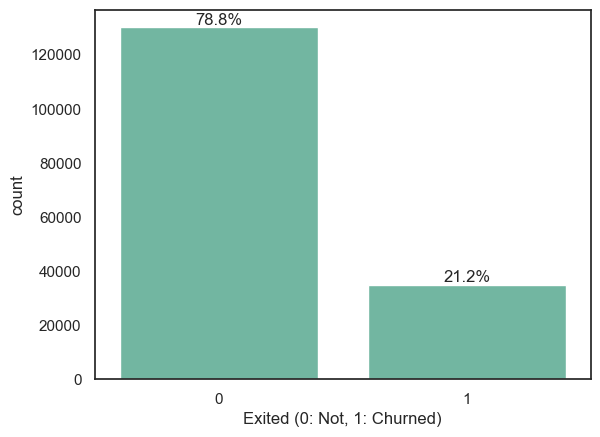

In [15]:
ax = sns.countplot(x=target, data=df_train)
ax.bar_label(ax.containers[0], labels=[f'{100 * p / len(df_train):.1f}%' for p in df_train[target].value_counts()])
plt.xlabel('Exited (0: Not, 1: Churned)')
plt.show()


### 2-6. Visualization : Distribution og all features

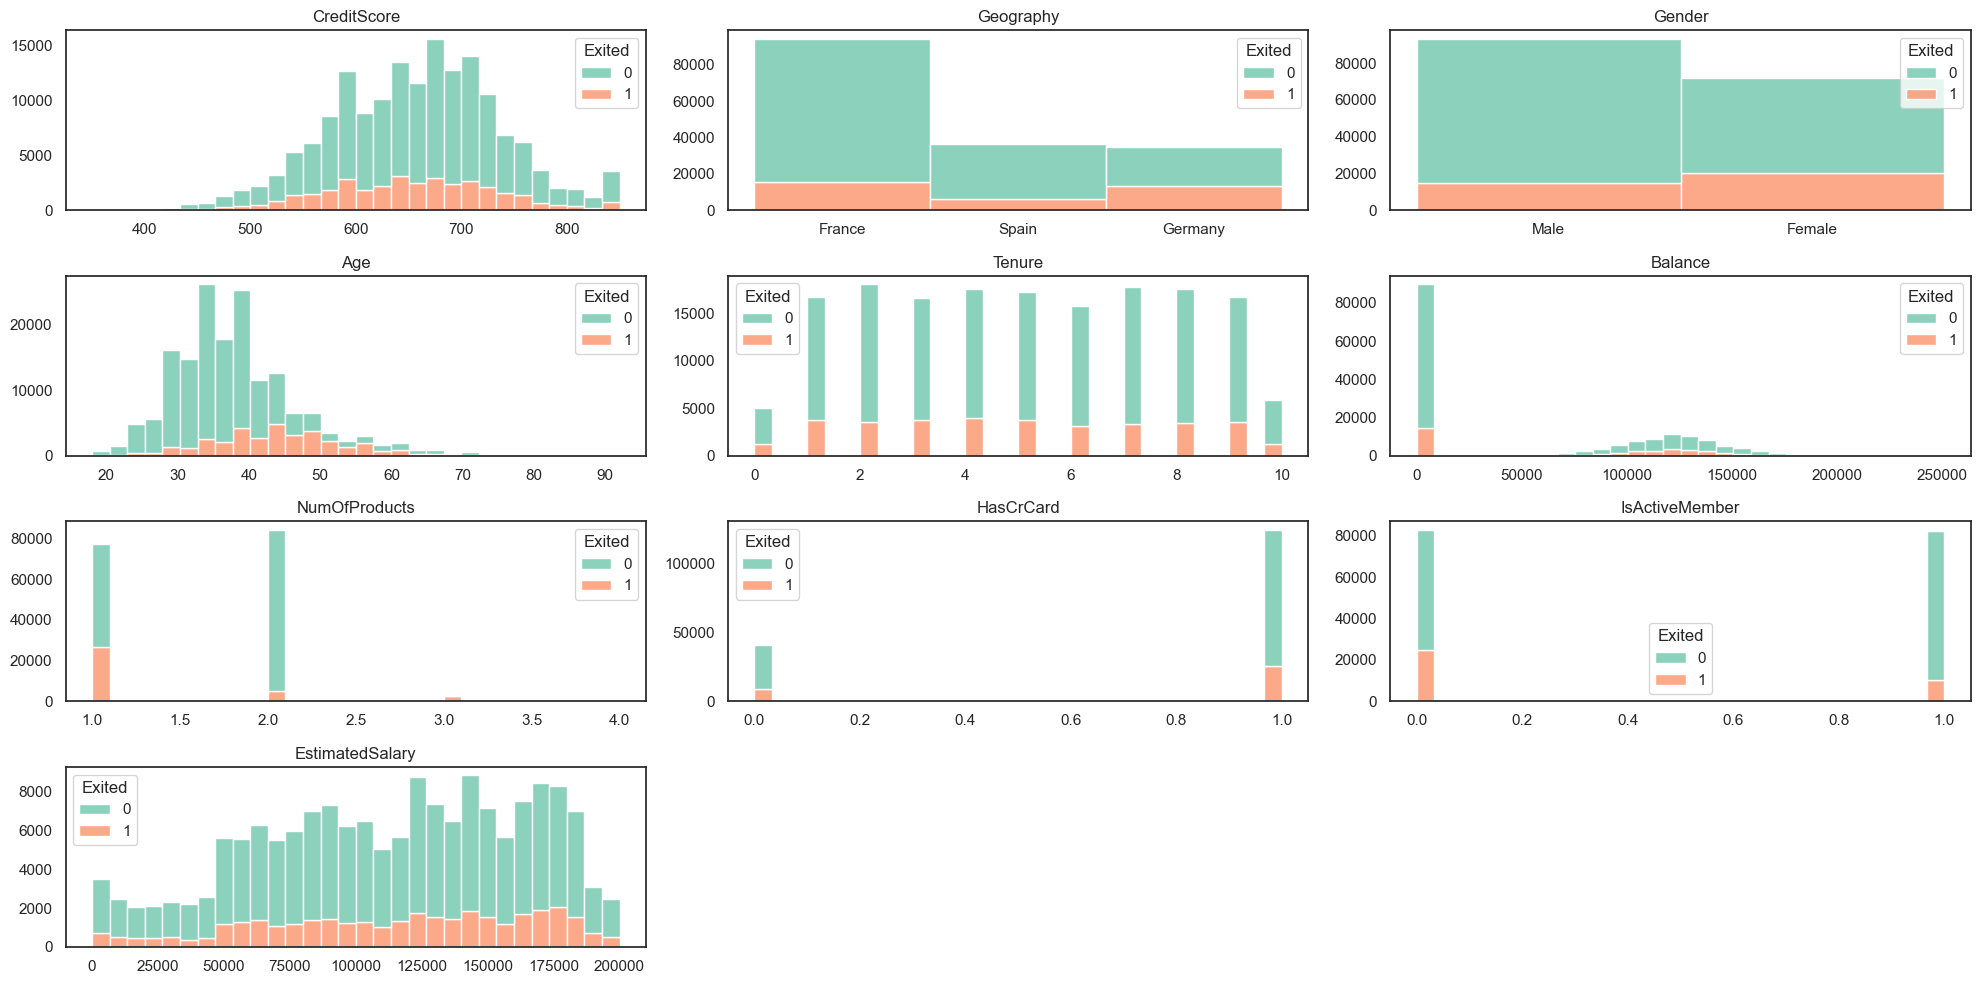

In [16]:
train_columns = df_train.drop(['Surname'], axis=1)

num_cols = train_columns.drop('Exited', axis=1).columns
n_cols = 3 
n_rows = 4 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(data=train_columns, x=col, hue=target, multiple='stack', bins=30, ax=ax)
    ax.set_title(f'{col}')
    ax.set_xlabel('')
    ax.set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#それぞれ割合で何%か表に入れたい！！！！！！

In [17]:
# Create a new binary feature 'ZeroBalance'
df_train['ZeroBalance'] = (df_train['Balance'] == 0).astype(int)
df_test['ZeroBalance'] = (df_test['Balance'] == 0).astype(int)

## 3. Feature Engineering

### 3-1. TFIDF-PCA (Text Transformation) for Surname

In [18]:
# pip install wordcloud

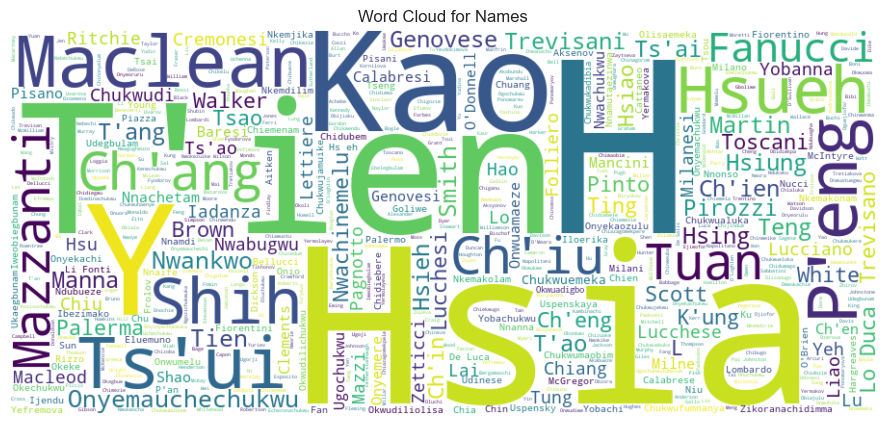

In [19]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=900, height=400, max_words=600, background_color='white').generate(' '.join(df_train['Surname']))

# Display the WordCloud
plt.figure(figsize=(20, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Names')
plt.show()


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [21]:
def tf_idf(df_train, df_test, column,n,p):
    vectorizer=TfidfVectorizer(max_features=n)
    vectors_train=vectorizer.fit_transform(df_train[column])
    vectors_test=vectorizer.transform(df_test[column])
    
    svd=TruncatedSVD(p)
    x_pca_train=svd.fit_transform(vectors_train)
    x_pca_test=svd.transform(vectors_test)
    tfidf_df_train=pd.DataFrame(x_pca_train)
    tfidf_df_test=pd.DataFrame(x_pca_test)

    
    cols=[(column+"_tfidf_"+str(f)) for f in tfidf_df_train.columns]
    tfidf_df_train.columns=cols
    tfidf_df_test.columns=cols
    df_train=pd.concat([df_train,tfidf_df_train], axis="columns")
    df_test=pd.concat([df_test,tfidf_df_test], axis="columns")
    
    return df_train, df_test

df_train,df_test=tf_idf(df_train,df_test,"Surname",1000,5)
df_train.drop(columns=["Surname"], inplace=True)
df_test.drop(columns=["Surname"], inplace=True)


In [22]:
df_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,Surname_tfidf_truncatedsvd0,Surname_tfidf_truncatedsvd1,Surname_tfidf_truncatedsvd2,Surname_tfidf_truncatedsvd3,Surname_tfidf_truncatedsvd4
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0,1,-1.444126e-07,-0.000001,5.408945e-07,-1.197272e-06,0.000007
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0,1,1.125891e-06,-0.000001,-3.780535e-06,7.327030e-06,0.000024
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0,1,-1.874520e-03,-0.000652,3.842442e-03,4.850237e-03,-0.028742
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0,0,-1.788621e-04,-0.000690,1.805656e-03,9.049374e-03,-0.030487
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0,1,-2.888705e-08,0.000001,5.654700e-07,-7.477832e-07,-0.000005


In [23]:
df_test.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,ZeroBalance,Surname_tfidf_truncatedsvd0,Surname_tfidf_truncatedsvd1,Surname_tfidf_truncatedsvd2,Surname_tfidf_truncatedsvd3,Surname_tfidf_truncatedsvd4
0,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75,1,-0.000011,-0.000089,-0.000011,-0.000349,0.000097
1,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27,1,0.000000,0.000000,0.000000,0.000000,0.000000
2,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09,1,0.000000,0.000000,0.000000,0.000000,0.000000
3,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57,1,-0.000008,0.000001,0.000012,-0.000048,-0.000088
4,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00,0,0.000000,0.000000,0.000000,0.000000,0.000000


### 3-2. Encoding

In [24]:
# One hot encode to the 'Geophraphy and 'Gender'
categorical_features = ['Geography', 'Gender']

# One-hot encode the categorical features
df_train = pd.get_dummies(df_train, columns=categorical_features, drop_first=True)
df_test = pd.get_dummies(df_test, columns=categorical_features, drop_first=True)

### 3-3. Handling outliers

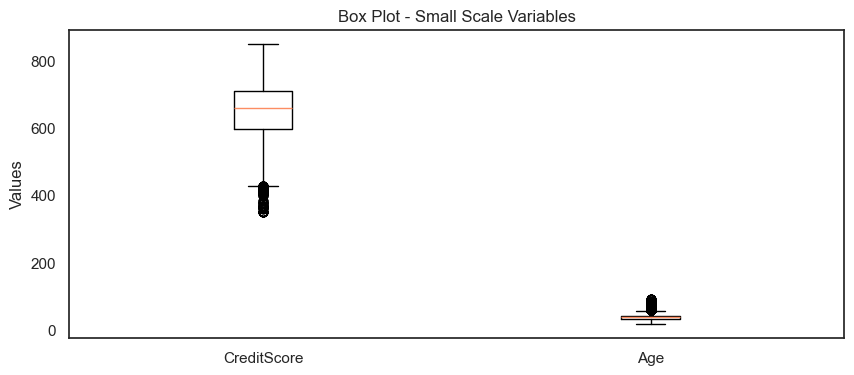

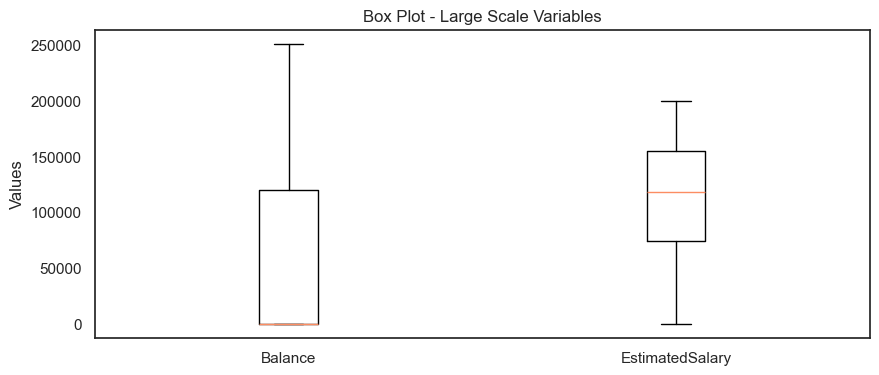

In [25]:
# 小さい値の変数（CreditScore, Age, Tenure）
small_scale_cols = ['CreditScore', 'Age']
# 大きい値の変数（Balance, EstimatedSalary）
large_scale_cols = ['Balance', 'EstimatedSalary']

# 小さいグループ
plt.figure(figsize=(10, 4))
plt.boxplot([df_train[col] for col in small_scale_cols], labels=small_scale_cols)
plt.title('Box Plot - Small Scale Variables')
plt.ylabel('Values')
plt.show()

# 大きいグループ
plt.figure(figsize=(10, 4))
plt.boxplot([df_train[col] for col in large_scale_cols], labels=large_scale_cols)
plt.title('Box Plot - Large Scale Variables')
plt.ylabel('Values')
plt.show()


In [26]:
# pip install sweetviz

In [39]:
df_train.duplicated().sum()

56

In [27]:
# pip install --upgrade ipywidgets

In [28]:
import sweetviz as sv
report = sv.compare([df_train, "Train Data"], [df_test, "Test Data"])


                                             |      | [  0%]   00:00 -> (? left)


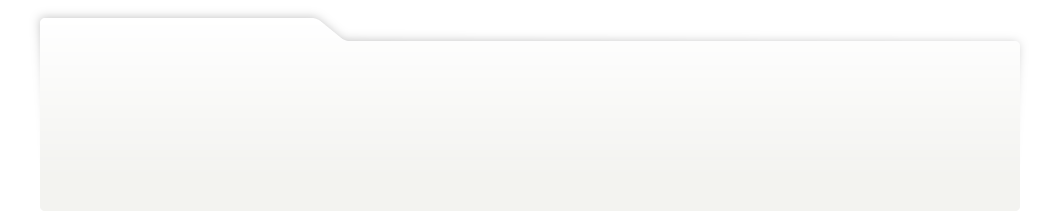
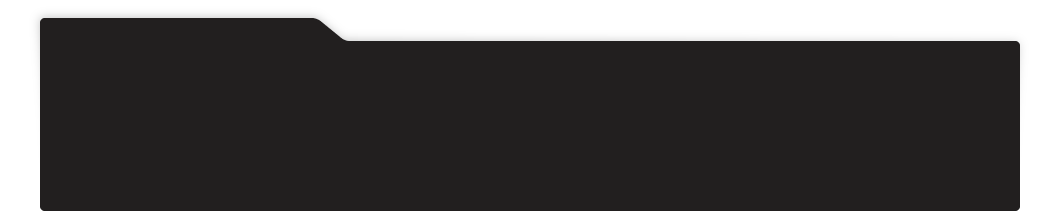
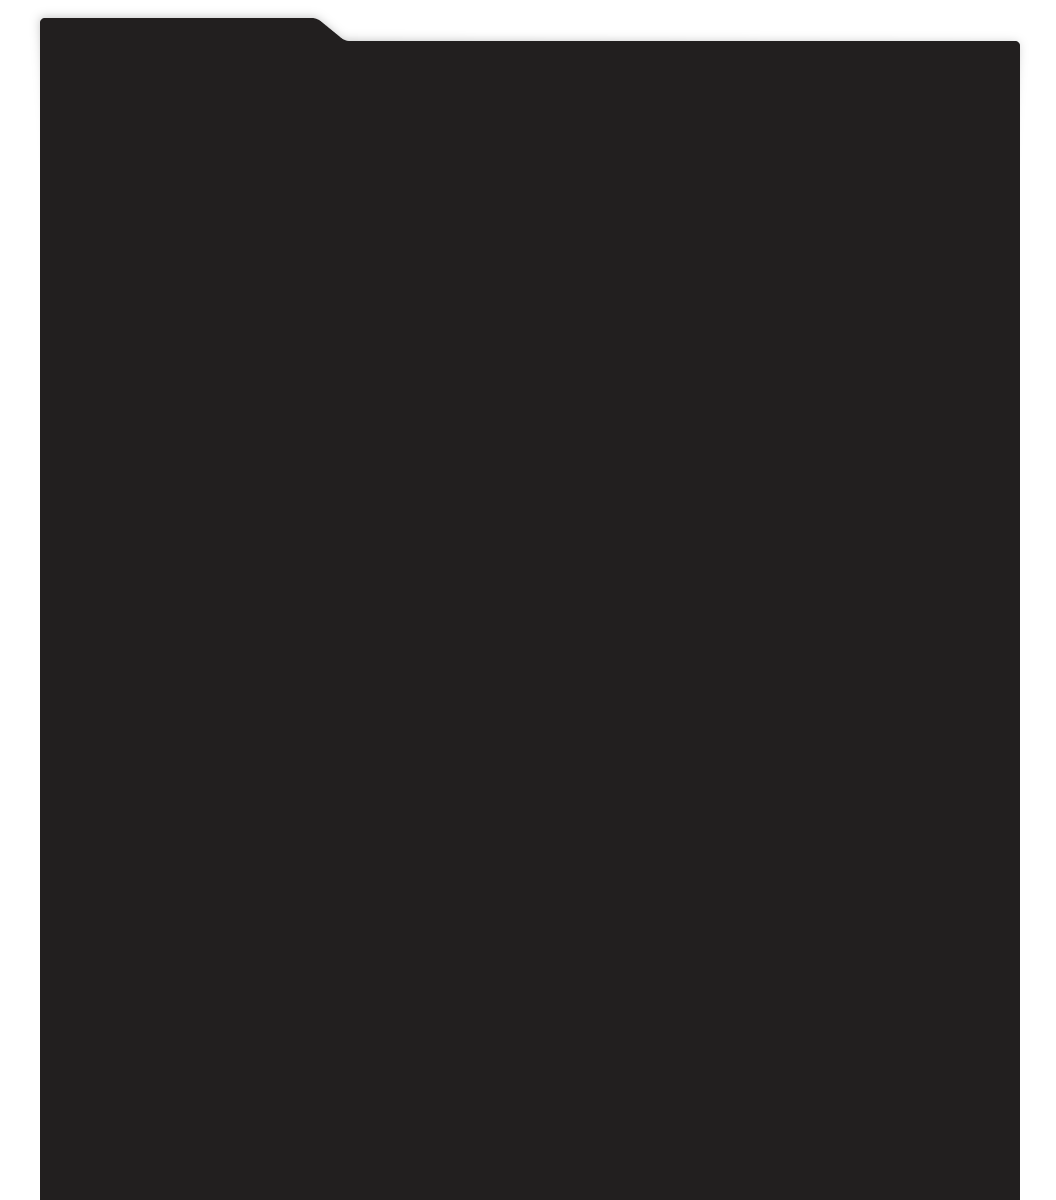
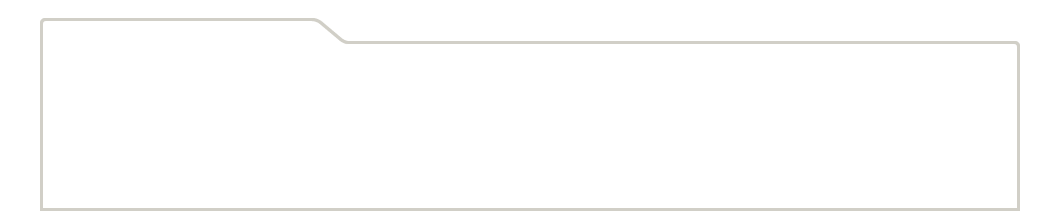
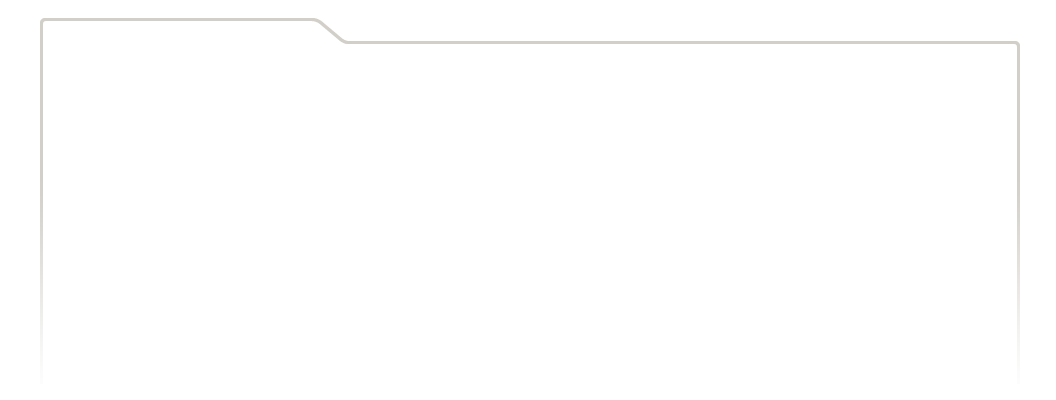
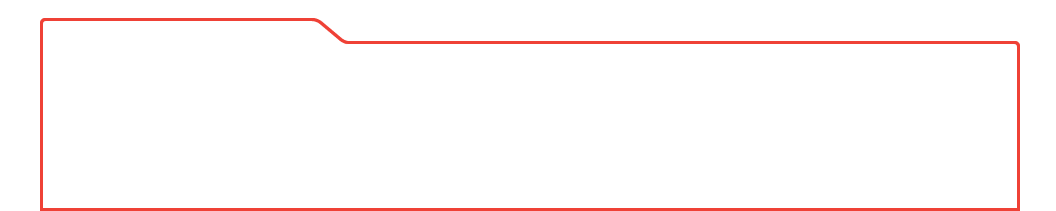
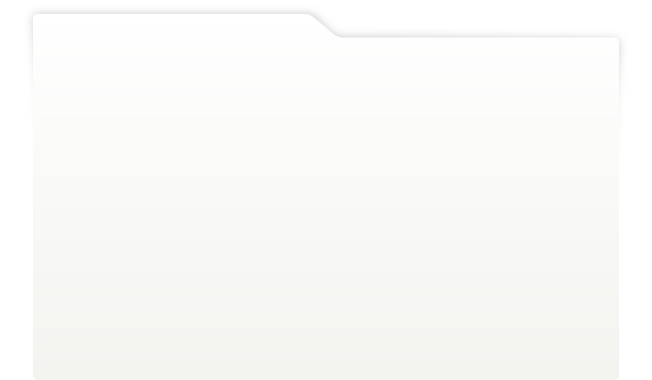
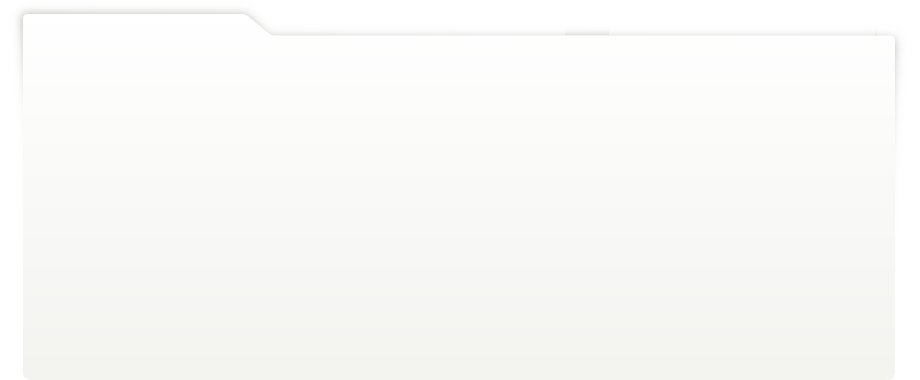
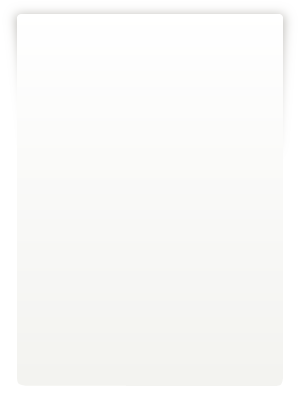
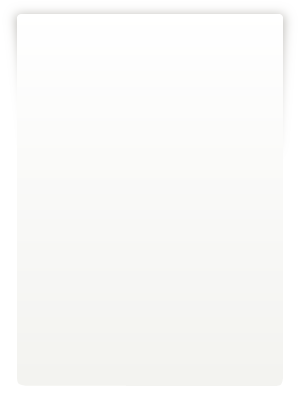
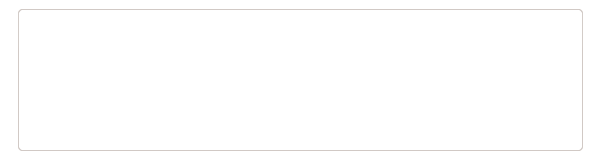
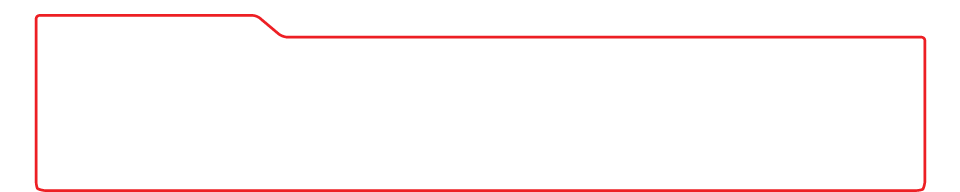
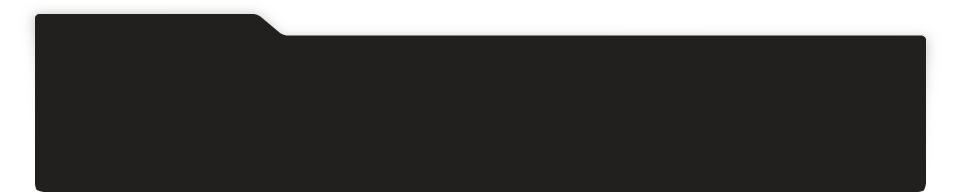
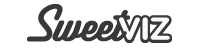
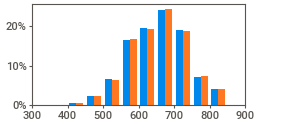
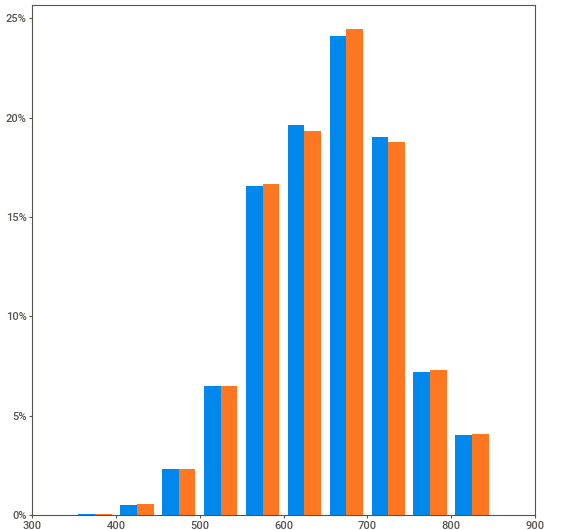
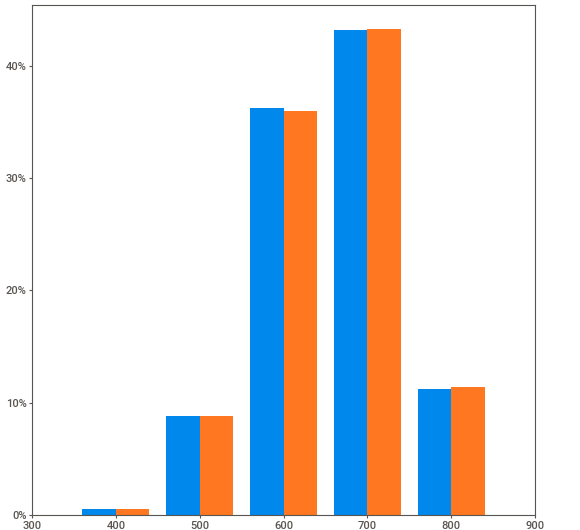
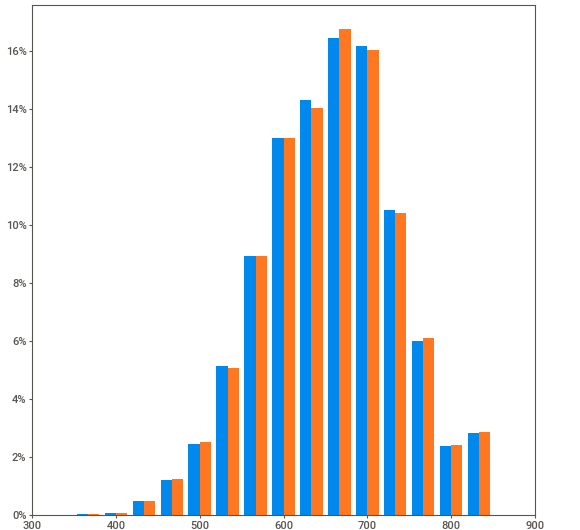
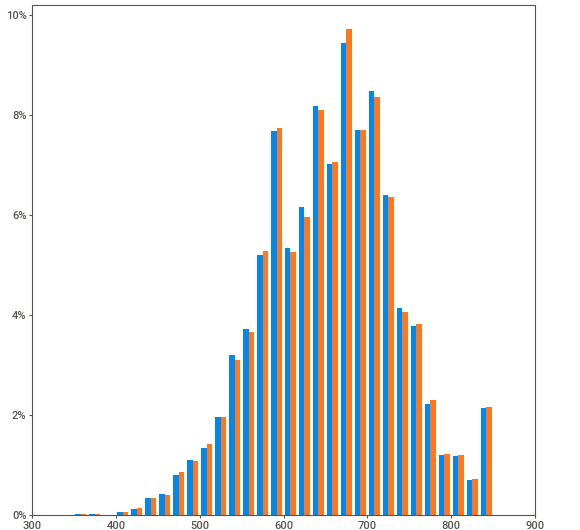
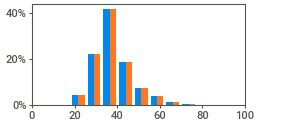
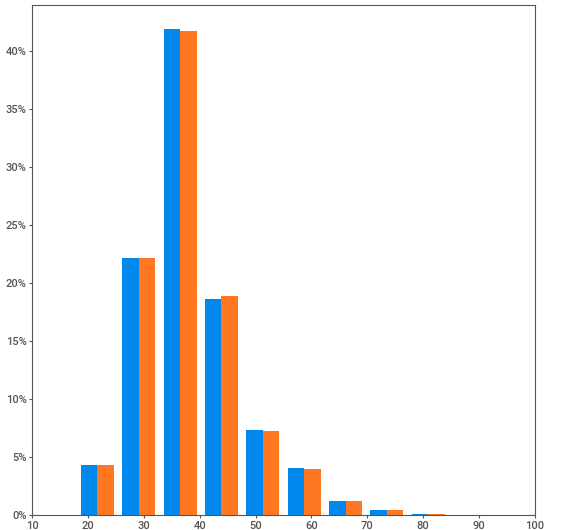
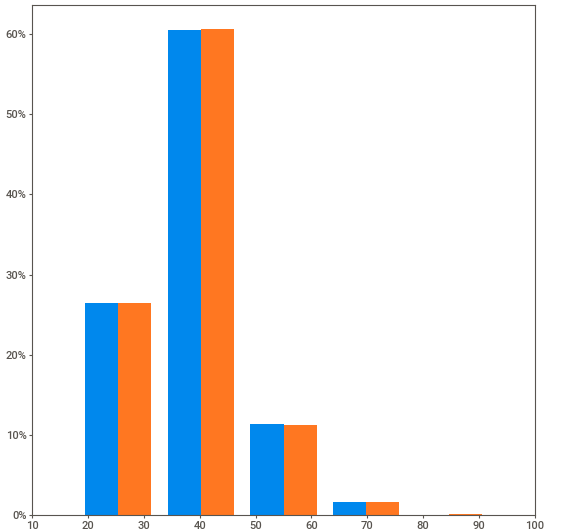
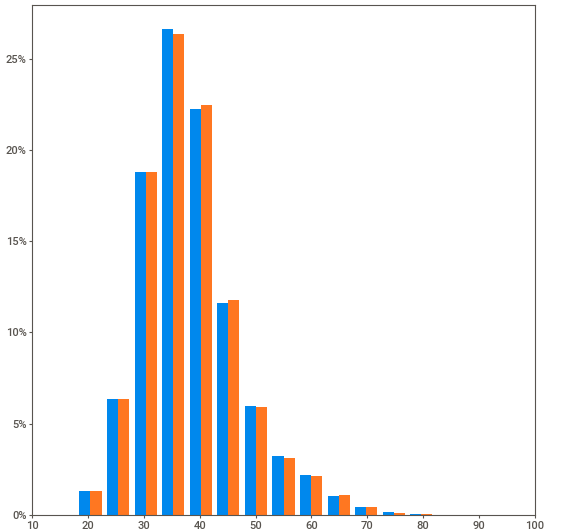
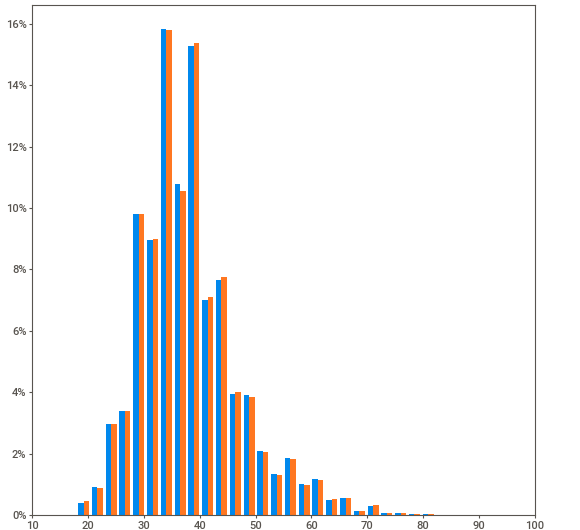
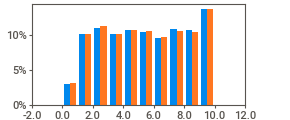
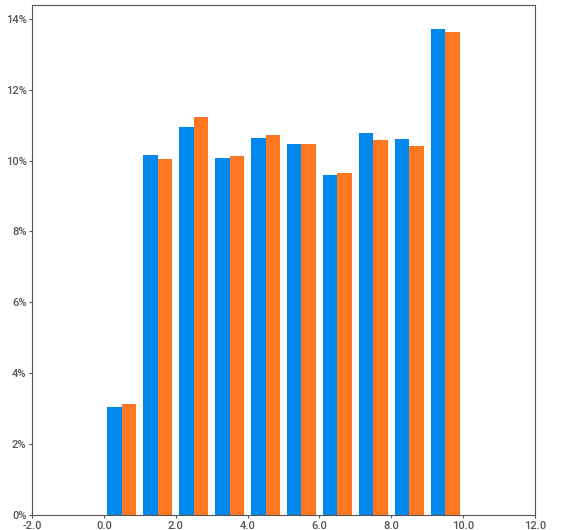
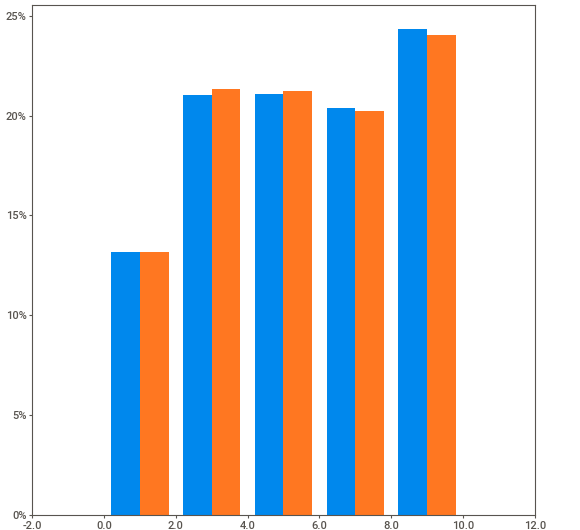
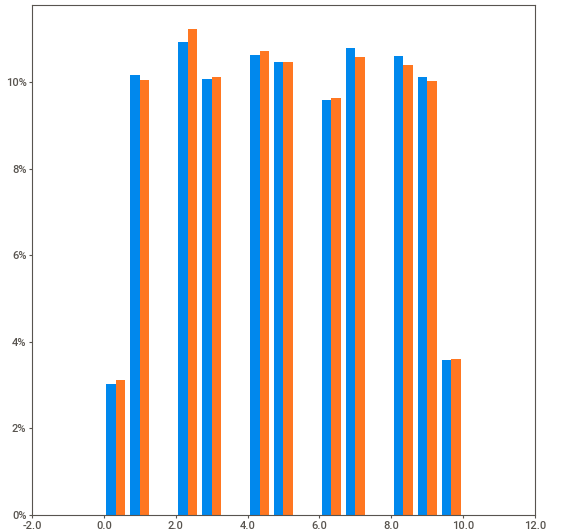
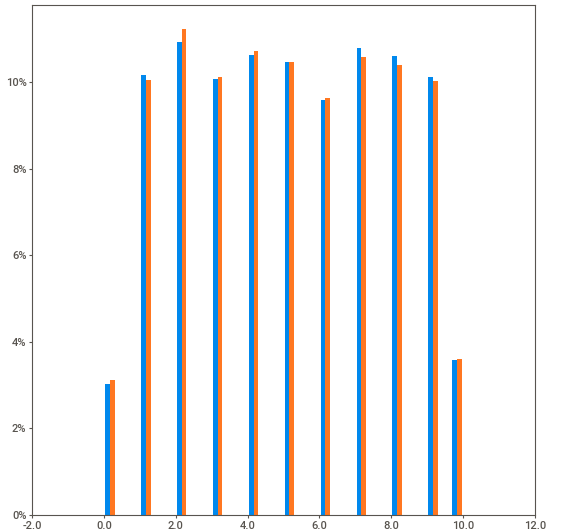
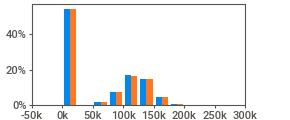
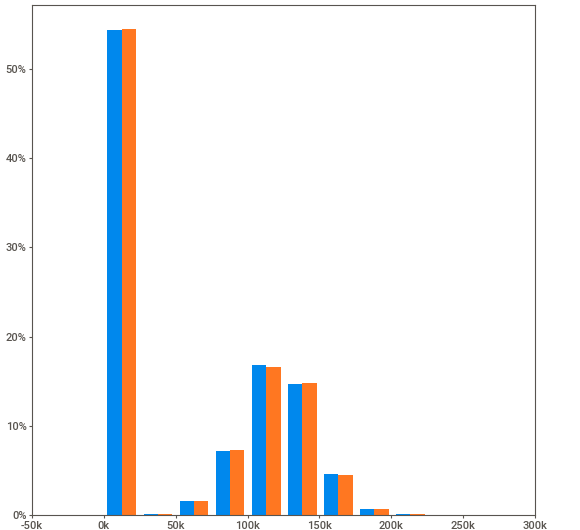
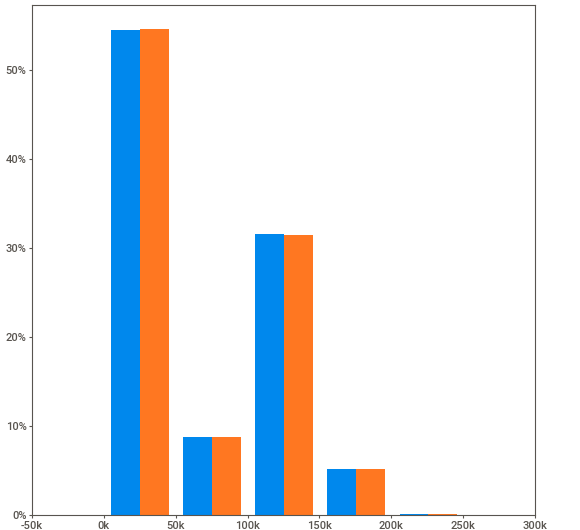
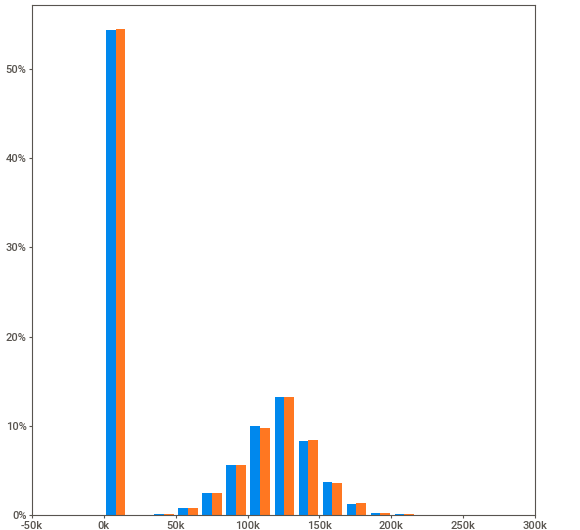
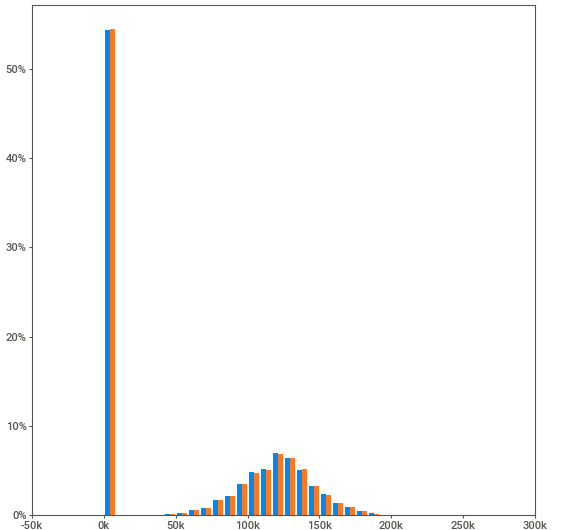
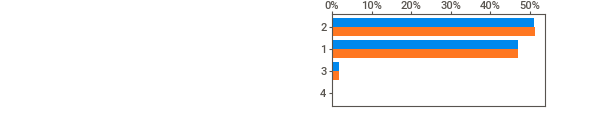
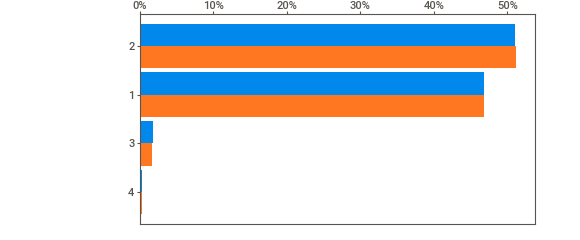
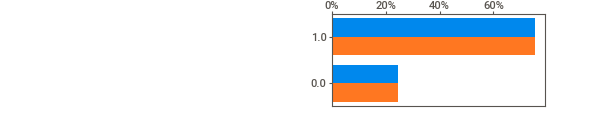
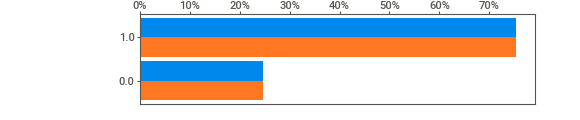
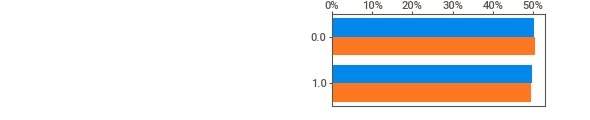
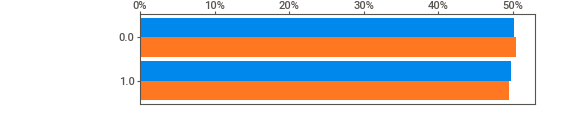
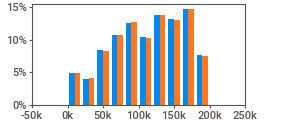
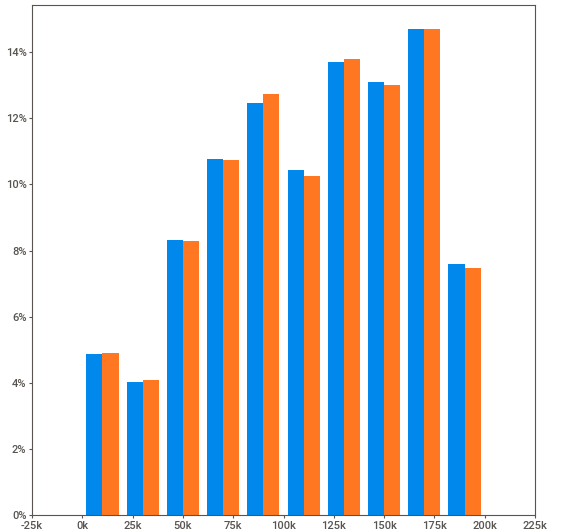
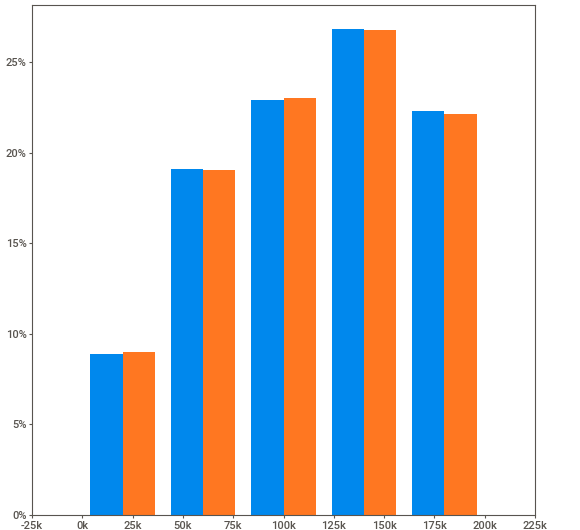
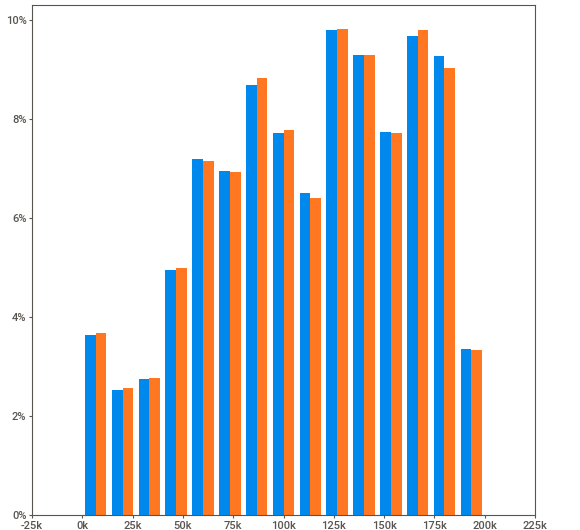
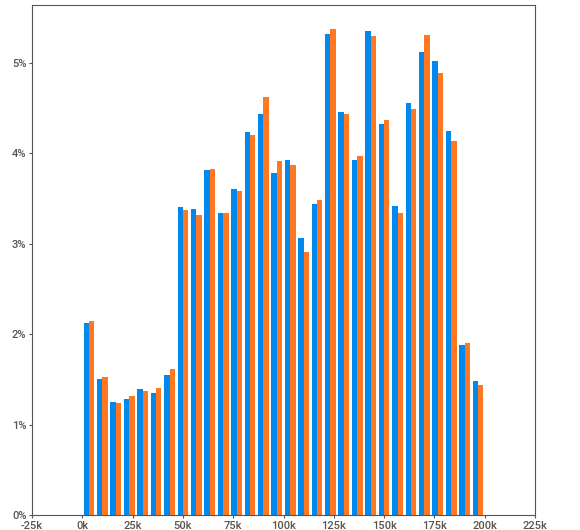
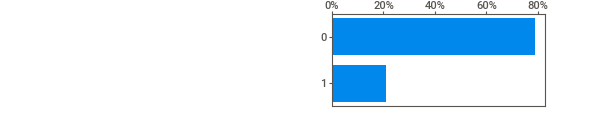
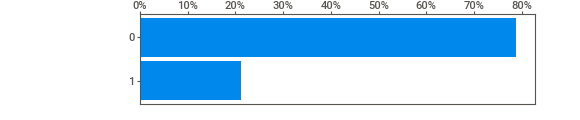
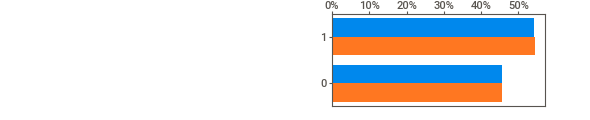
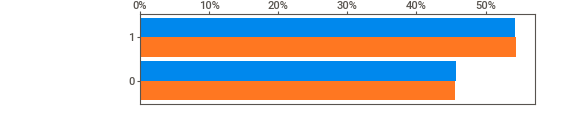
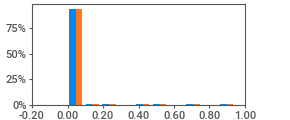
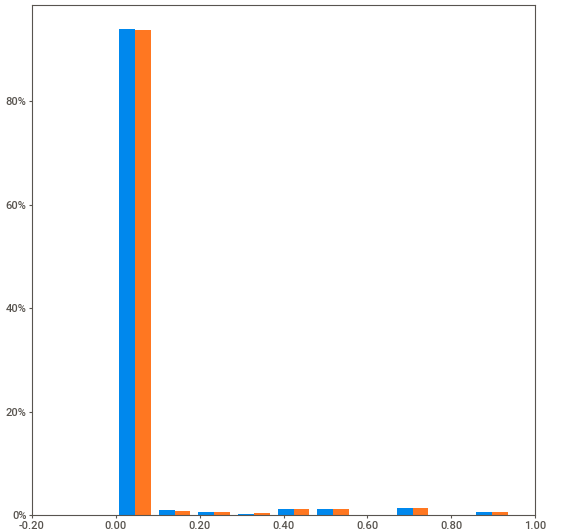
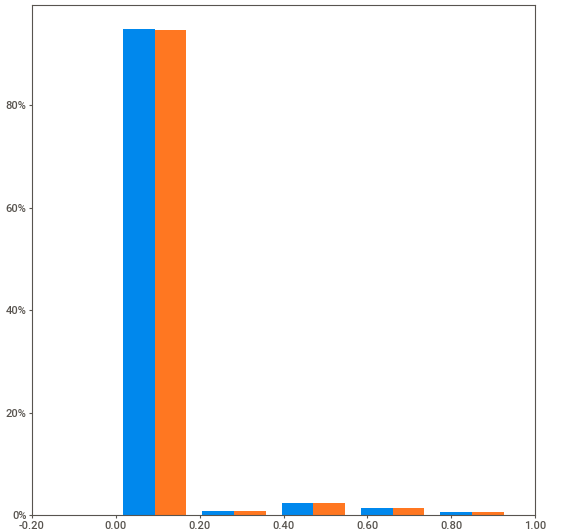
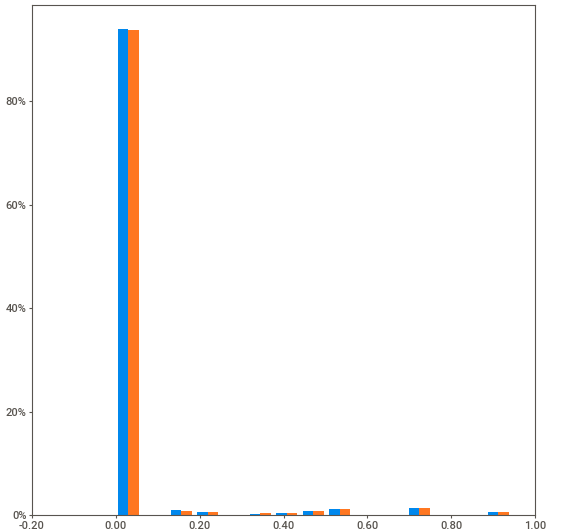
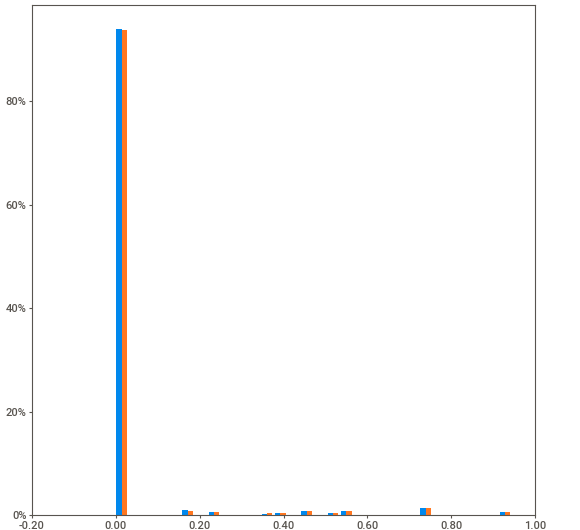
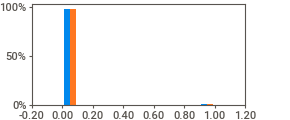
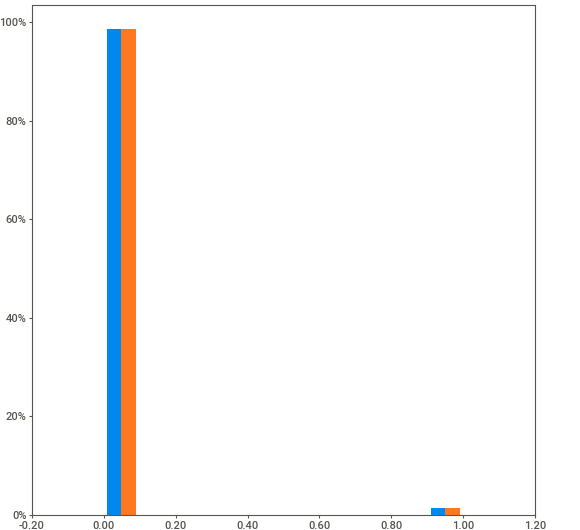
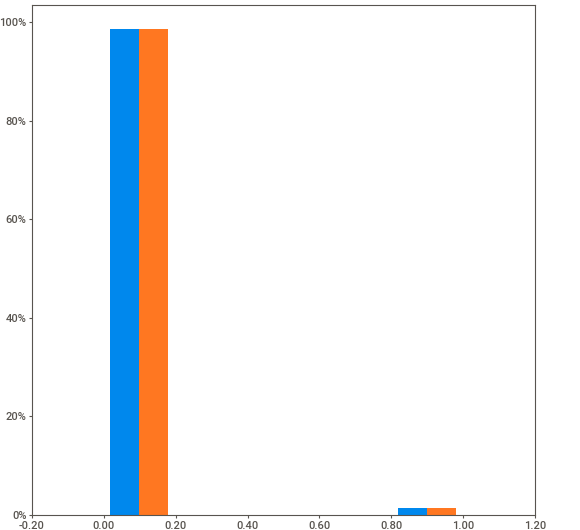
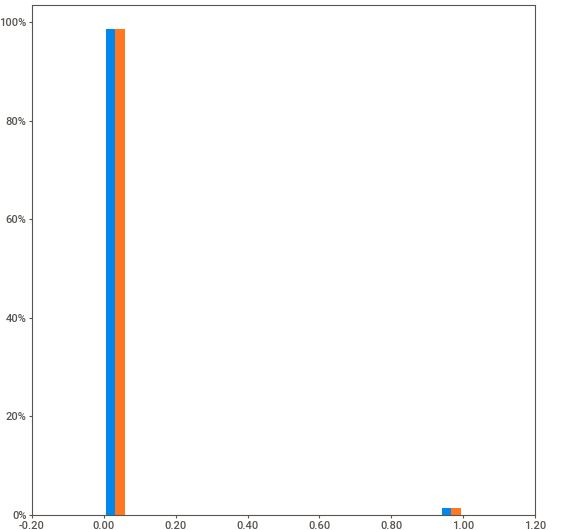
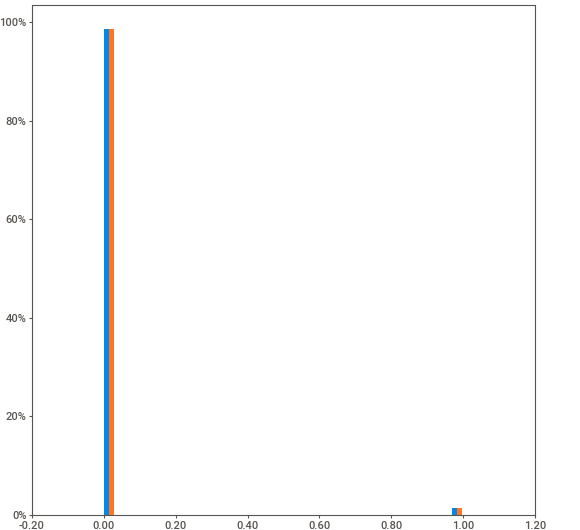
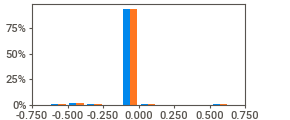
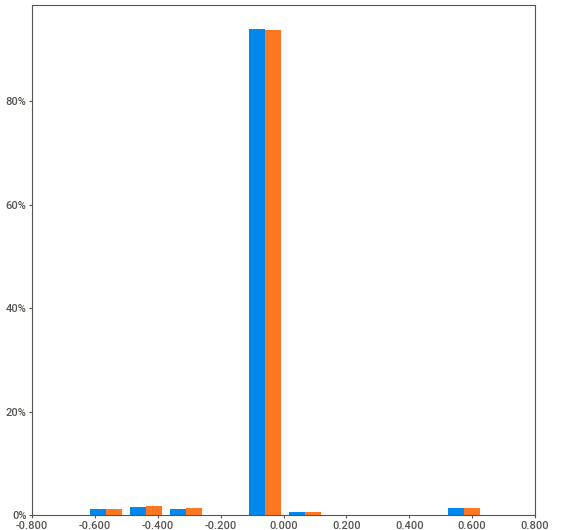
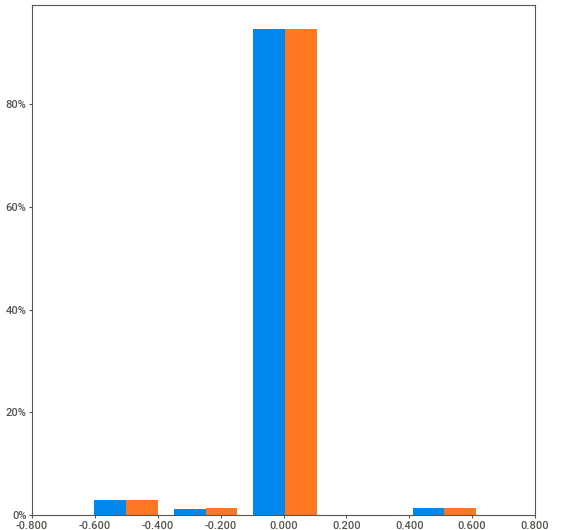
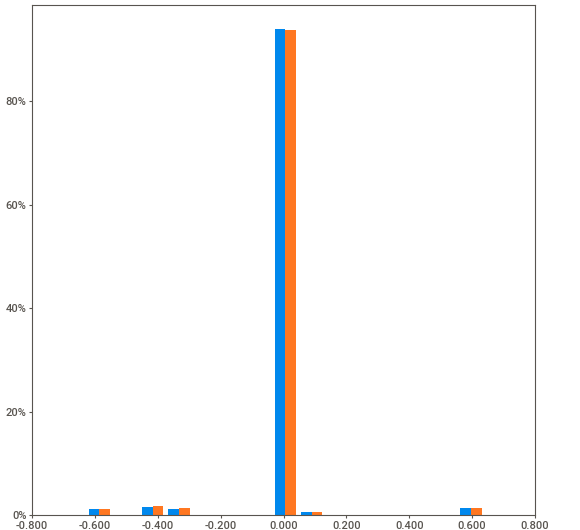
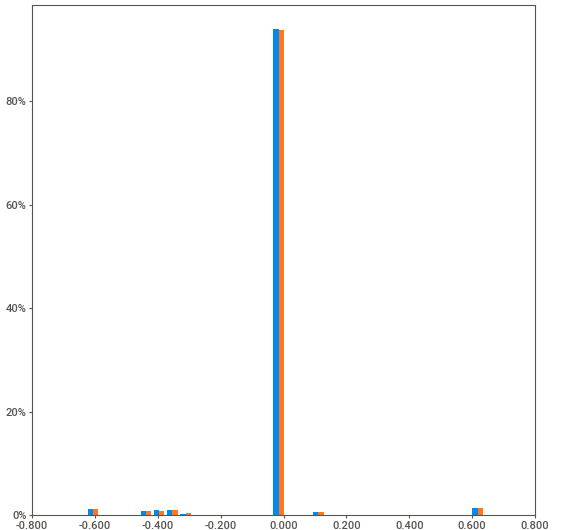
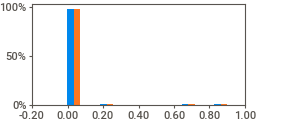
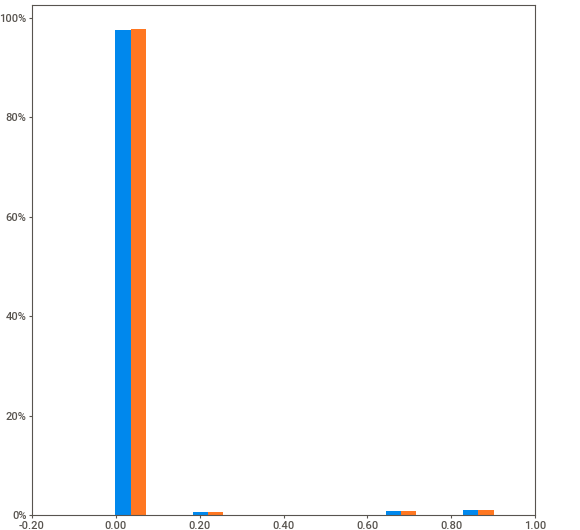
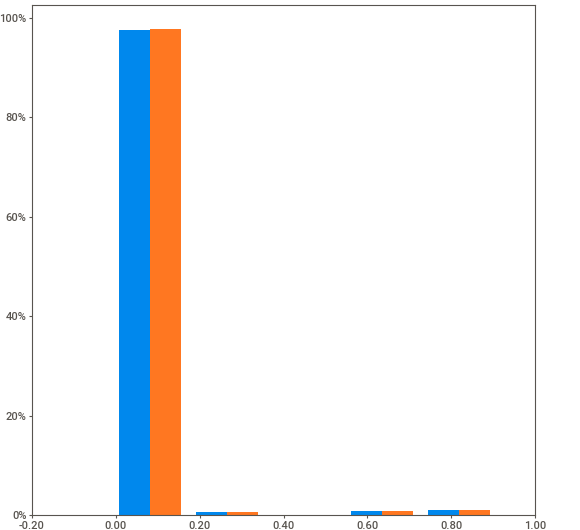
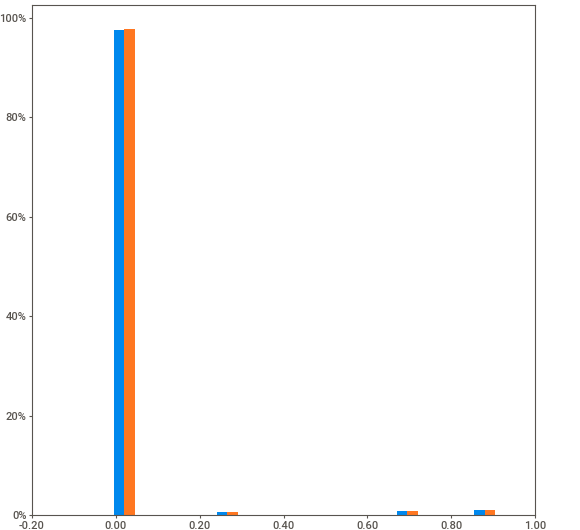
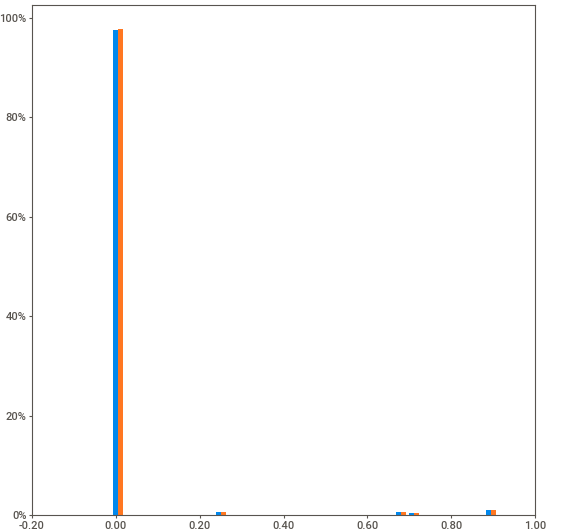
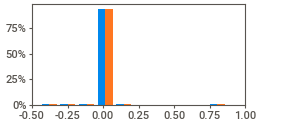
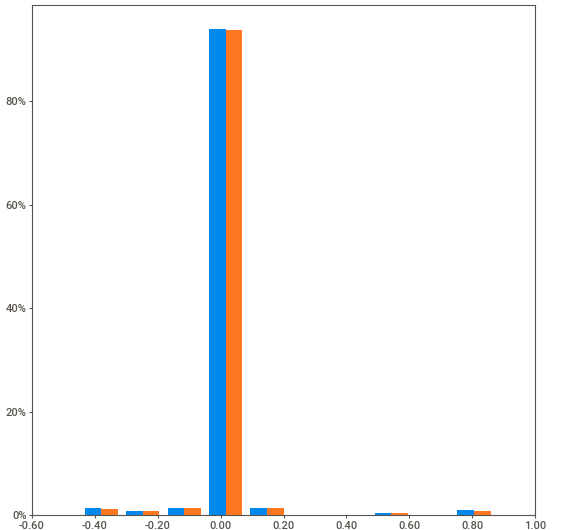
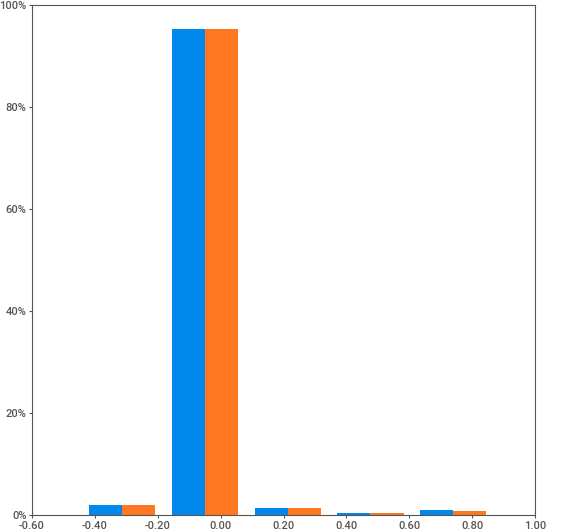
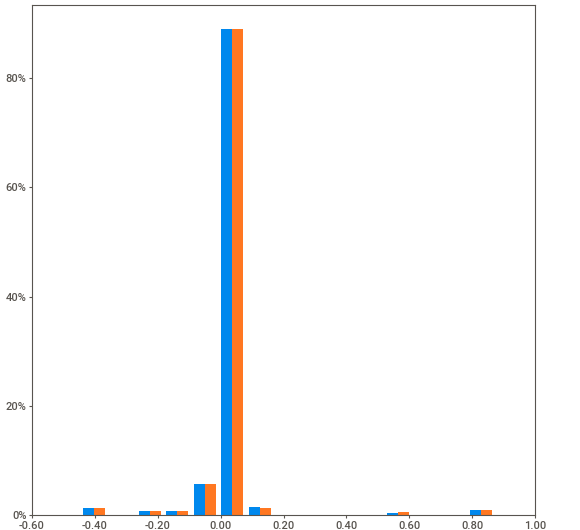
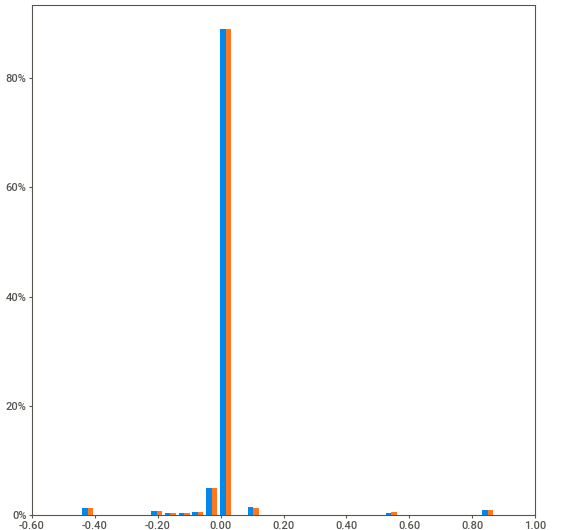
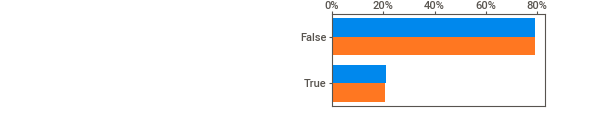
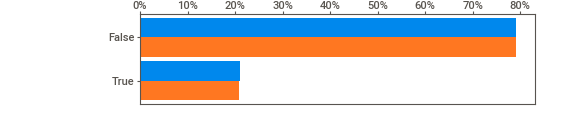
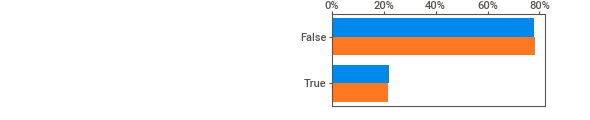
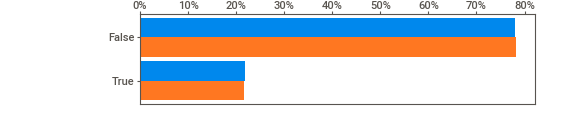
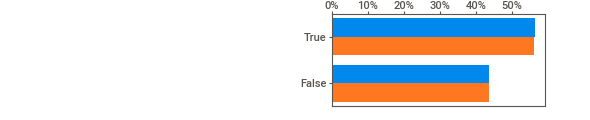
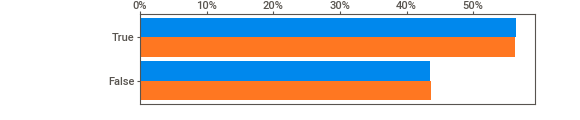
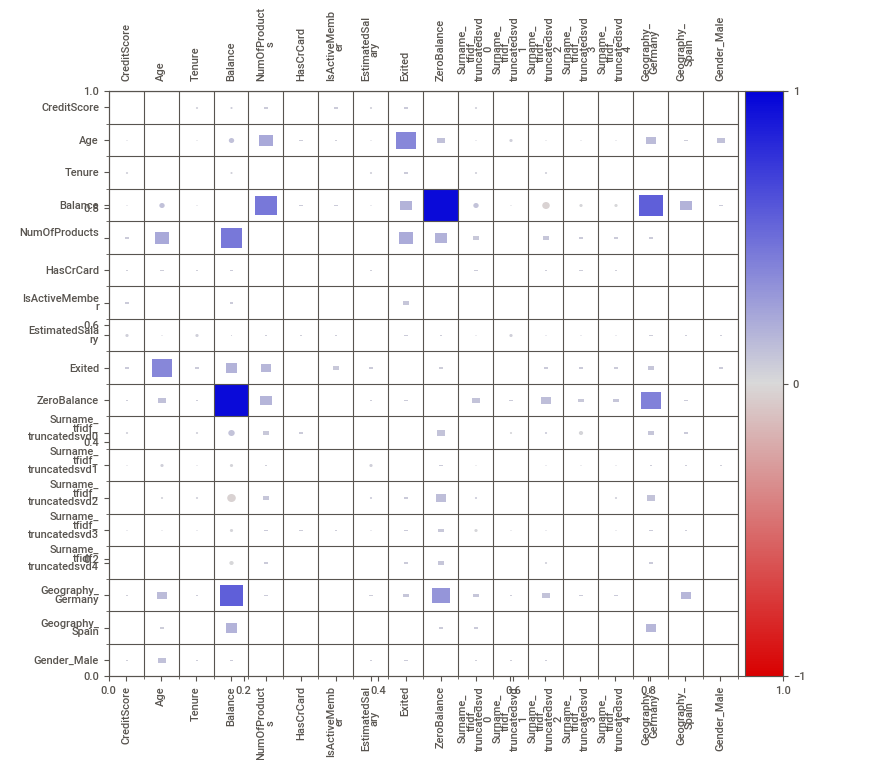
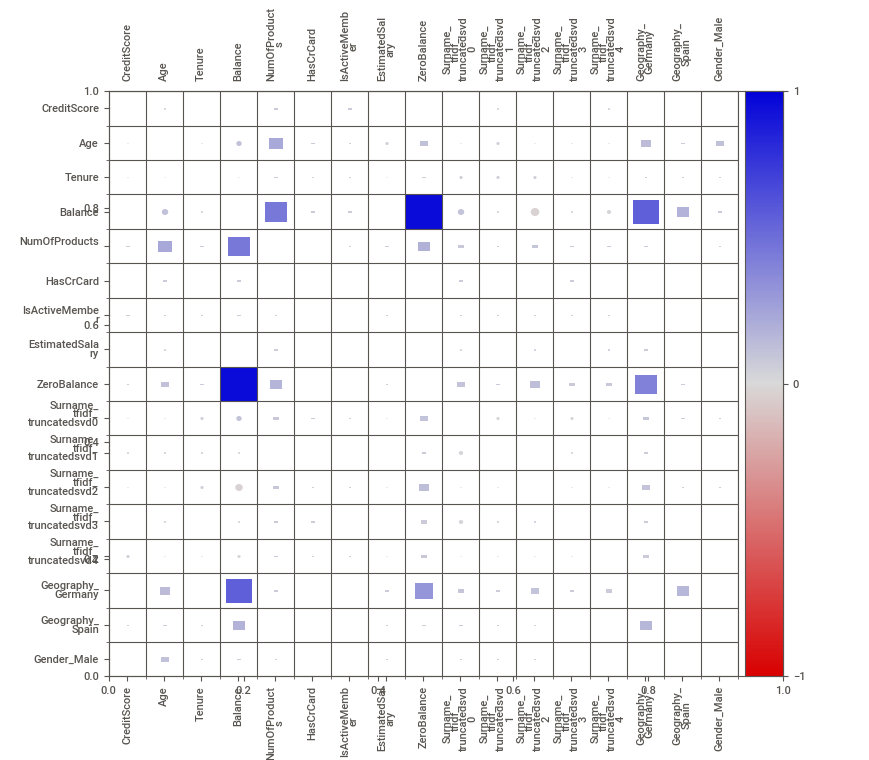

In [29]:
report.show_notebook(w="100%", h="full")

In [30]:
# Select X and y
X = df_train.drop(columns=['Exited'])
y = df_train['Exited']

In [31]:
from sklearn.preprocessing import LabelEncoder

# Label encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


In [32]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# Define XGBoost parameters
xgb_params = {
    'n_estimators': 1314,
    'learning_rate': 0.01852574097446641,
    'max_depth': 6,
    'subsample': 0.7110872617281421,
    'colsample_bytree': 0.45420164989131234,
    'min_child_weight': 6,
    'tree_method': 'hist', # for GPU P100 Accelerator performance in kaggle environment
    'verbosity': 0,
    'eval_metric': 'auc',
    'random_state': 42
    # Additional parameters can be added here
}

# Number of folds for StratifiedKFold
n_splits = 10

# StratifiedKFold
stratkf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Cross-validation results
cv_results = []

# Stratified k-fold cross-validation
for fold, (train_idx, val_idx) in enumerate(stratkf.split(X, y_encoded)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    # XGBoost model
    xgb_model = XGBClassifier(**xgb_params)
    xgb_model.fit(X_train, y_train)

    # Predictions on the validation set
    y_val_pred_prob = xgb_model.predict_proba(X_val)[:, 1]

    # Evaluating the model using AUC
    auc_score = roc_auc_score(y_val, y_val_pred_prob)
    print(f'Fold {fold + 1}, AUC on Validation Set: {auc_score}')
     # Results
    cv_results.append(auc_score)

# Average AUC across all folds
average_auc = sum(cv_results) / n_splits
print(f'\nAverage AUC across {n_splits} folds: {average_auc}')

Fold 1, AUC on Validation Set: 0.8965665537741354
Fold 2, AUC on Validation Set: 0.8919679701774977
Fold 3, AUC on Validation Set: 0.896922479082662
Fold 4, AUC on Validation Set: 0.8940185343402199
Fold 5, AUC on Validation Set: 0.8926971366989409
Fold 6, AUC on Validation Set: 0.9005071090168394
Fold 7, AUC on Validation Set: 0.893369952713375
Fold 8, AUC on Validation Set: 0.8976927664431974
Fold 9, AUC on Validation Set: 0.8938031595962991
Fold 10, AUC on Validation Set: 0.8924794162627216

Average AUC across 10 folds: 0.8950025078105888


In [33]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier

# Number of unique classes
num_classes = len(np.unique(y_encoded))

lgbm_params = {
    'objective': 'binary',
    # Removed 'num_class'
    'max_depth': 37, 
    'num_leaves': 54,
    'min_child_samples': 62,
    'min_child_weight': 0.022953277553297614,
    'learning_rate': 0.04039521672684383, 
    'n_estimators': 802, 
    'subsample': 0.21195058174029469,
    'colsample_bytree': 0.306228052372081, 
    'reg_alpha': 1.8695394080588894, 
    'reg_lambda': 1.2165814869632903,
    'random_state': 42,
    'verbose': -1  # Set verbose to -1 to silence LightGBM warnings
}

# StratifiedKFold for cross-validation
n_splits = 10
stratkf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

cv_results = []

for fold, (train_idx, val_idx) in enumerate(stratkf.split(X, y_encoded)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    # Initialize and train the LightGBM model
    lgbm_model = LGBMClassifier(**lgbm_params)
    lgbm_model.fit(X_train, y_train)

    # Predict probabilities on the validation set
    y_val_pred_prob = lgbm_model.predict_proba(X_val)[:, 1]

    # Evaluating the model using AUC
    auc_score = roc_auc_score(y_val, y_val_pred_prob)
    print(f'Fold {fold + 1}, AUC on Validation Set: {auc_score}')

 # Results
    cv_results.append(auc_score)

# Average AUC across all folds
average_auc = sum(cv_results) / n_splits
print(f'\nAverage AUC across {n_splits} folds: {average_auc}')

Fold 1, AUC on Validation Set: 0.8963468803490583
Fold 2, AUC on Validation Set: 0.8929855567281448
Fold 3, AUC on Validation Set: 0.8969106497518018
Fold 4, AUC on Validation Set: 0.8946524646732995
Fold 5, AUC on Validation Set: 0.8925876271932385
Fold 6, AUC on Validation Set: 0.9010683686189227
Fold 7, AUC on Validation Set: 0.8930701799332189
Fold 8, AUC on Validation Set: 0.8983620829075546
Fold 9, AUC on Validation Set: 0.893906979581908
Fold 10, AUC on Validation Set: 0.8923990696743253

Average AUC across 10 folds: 0.8952289859411474


In [34]:
from catboost import CatBoostClassifier

# CatBoost parameters
catboost_params = {
    'iterations': 341,
    'depth': 19, 
    'min_child_samples': 14,
    'learning_rate': 0.07273816528242245, 
    'grow_policy': 'Lossguide',
    'bootstrap_type': 'Bernoulli',
    'random_state': 42,
    'verbose': 0
}

n_splits = 10
stratkf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Cross-validation results
cv_results = []

for fold, (train_idx, val_idx) in enumerate(stratkf.split(X, y_encoded)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    # Initialize and train the CatBoost model
    cat_model = CatBoostClassifier(**catboost_params)
    cat_model.fit(X_train, y_train)

    y_val_pred_prob = cat_model.predict_proba(X_val)[:, 1]

    # Calculate AUC score
    auc_score = roc_auc_score(y_val, y_val_pred_prob)
    print(f'Fold {fold + 1}, AUC Score on Validation Set: {auc_score}')

    # Append results
    cv_results.append(auc_score)

# Average AUC score across all folds
average_auc = sum(cv_results) / n_splits
print(f'\nAverage AUC Score across {n_splits} folds: {average_auc}')

Fold 1, AUC Score on Validation Set: 0.8952631595858823
Fold 2, AUC Score on Validation Set: 0.8900539294242094
Fold 3, AUC Score on Validation Set: 0.8948876250982001
Fold 4, AUC Score on Validation Set: 0.8923005381405235
Fold 5, AUC Score on Validation Set: 0.8905002666260983
Fold 6, AUC Score on Validation Set: 0.8997503918395597
Fold 7, AUC Score on Validation Set: 0.8922736361152864
Fold 8, AUC Score on Validation Set: 0.8965417226044435
Fold 9, AUC Score on Validation Set: 0.8924795813358386
Fold 10, AUC Score on Validation Set: 0.8910417504687858

Average AUC Score across 10 folds: 0.8935092601238827


In [35]:
from sklearn.ensemble import VotingClassifier
Ensemble = VotingClassifier(estimators = [('xgb', xgb_model), ('lgb', lgbm_model), ('CB', cat_model)], 
                            voting='soft',
                            weights = [0.45,0.45,0.1] #Adjust weighting
                            )
Ensemble.fit(X, y_encoded)

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.45420164989131234,
                                            device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='auc',
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=...
                                             learning_rate=0.04039521672684383,
                                             max_depth=37, min_child_samples=62,
                                             min_child_weight=0.022953277553297614,
                                             n_estimators=802, num_leaves=54,
                                             objective='binary',
                                             random_state=42,
                                             reg_alpha=1.8695394080588894,
                                             reg_lambda=1.2165814869632903,
                                             subsample=0.21195058174029469,
                                             verbose=-1)),
                             ('CB',
                              <catboost.core.CatBoostClassifier object at 0x131bdf090>)],
                 voting='soft', weights=[0.45, 0.45, 0.1])

In [36]:
y_pred = Ensemble.predict_proba(df_test)
y_pred = pd.DataFrame(y_pred[:, 1])
y_pred.columns = ['Exited']
y_pred.head()

,Exited
0,0.016550
1,0.736082
2,0.038964
3,0.252694
4,0.354430


In [37]:

submission = pd.DataFrame()
submission = y_pred
ids = df_submission['id']
submission['id'] = ids
submission.head()

,Exited,id
0,0.016550,165034
1,0.736082,165035
2,0.038964,165036
3,0.252694,165037
4,0.354430,165038


In [38]:
submission.to_csv('submission_project.csv', index= False)